In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## Load and read the dataset

In [34]:
## Read the dataset
df = pd.read_csv('Datasets\height-weight (1).csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


**PLOT HEIGHT AND WEIGHT IN SCATTER**

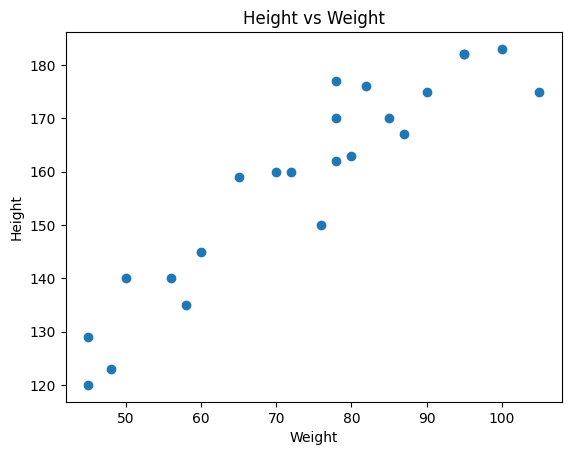

In [35]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Height vs Weight')
plt.show()

## divide our dataset into independent and dependent feature

In [36]:
x=df[['Weight']] # independent features
y=df['Height'] # dependent features


In [37]:
x

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [38]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

## Train test split

In [39]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
x.shape

(23, 1)

In [41]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

## Standardize the data

In [42]:
## standardize the dataset ( train independent data)
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()

In [44]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


**Plotting x train and y train**

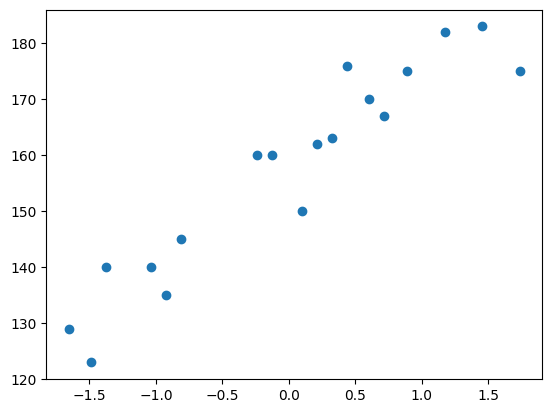

In [45]:
plt.scatter(x_train,y_train)

## Train the Simple Linear Regression Model

In [47]:
## Train the model 
from sklearn.linear_model  import LinearRegression

In [ ]:
regressor = LinearRegression()

In [49]:
regressor.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
print("The slope or coefficient:", regressor.coef_)
print("The intercept:", regressor.intercept_)

The slope or coefficient: [17.03440872]
The intercept: 157.5


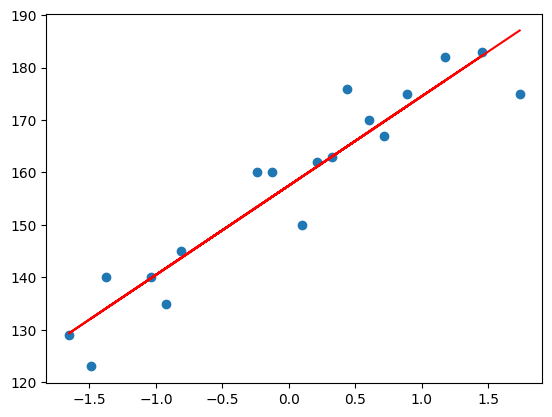

In [ ]:
plt.scatter(x_train,y_train)# plotting trainingd data
plt.plot(x_train,regressor.predict(x_train),color='red') ## Creating the best fit line

**Prediction of train data**
1.predicted height output = intercept +coef_(Weights)
2.y_pred_train = 157 + 17.03(x_train)<br><br>


**Prediction of test data**
1.predicted height output = intercept+coef_(Weights)
2.y_pred_test =157 +17.03(x_test)

In [55]:
y_pred_test = regressor.predict(x_test)

In [57]:
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

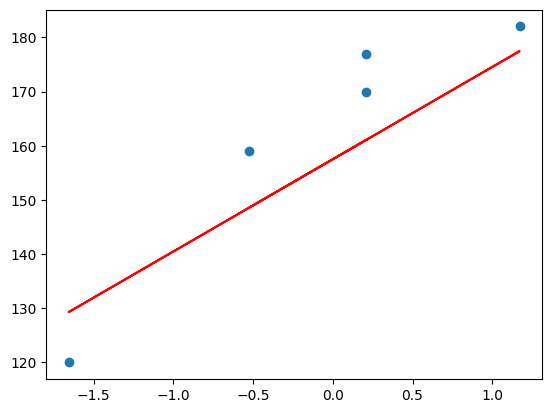

In [58]:
plt.scatter(x_test,y_test)# plotting trainingd data
plt.plot(x_test,regressor.predict(x_test),color='red') ## Creating the best fit line

In [59]:
## Performance Metrics
## MSE,MAE,RMSE,R2 and adjusted R2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [60]:
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)  
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


In [61]:
score =r2_score(y_test,y_pred_test)
score

0.776986986042344

In [62]:
#Display adjusted R=Squared
1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.7026493147231252

## ASSUMPTION

In [63]:
regressor

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
## new data point weight is 80
scaled_weight=scaler.transform([[80]])
scaled_weight

C:\Users\user\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

**PREDICTION ON NEW DATA**

In [65]:
regressor.predict([scaled_weight[0]])

array([163.01076266])

**ASSUMPTIONS**

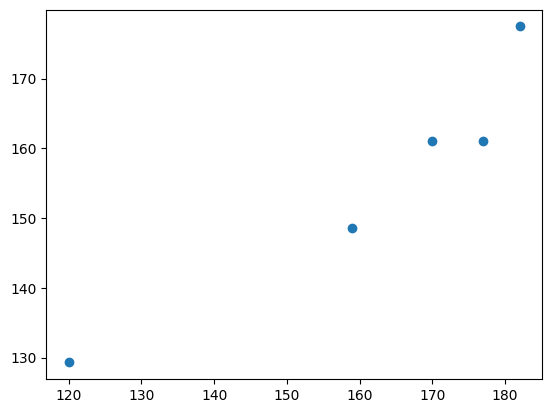

In [67]:
## Plot a scatter plot for the prediction
plt.scatter(y_test,y_pred_test)# plotting trainingd data

it should be linear

In [68]:
## Rediduals
residuals =y_test - y_pred_test

In [69]:
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

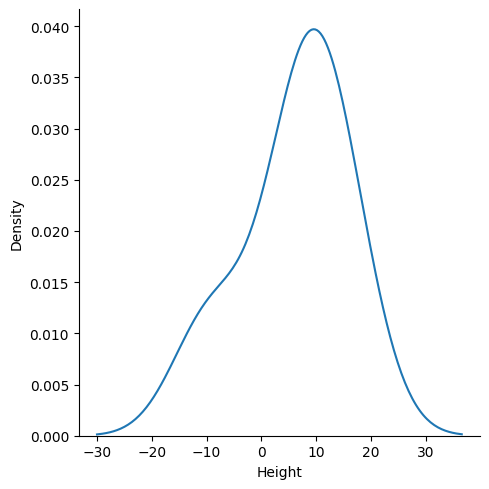

In [72]:
## plot this residuals
import seaborn as sns
sns.displot(residuals,kind='kde')

if we get kind of normal distribution then we can say we created a better model

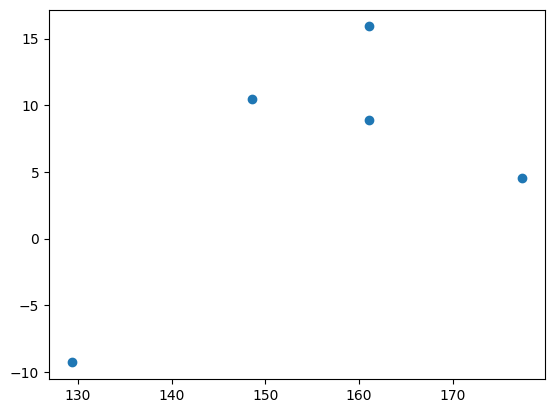

In [73]:
## Scatter plot with respect to predictiona and residulas
## uniform distribution
plt.scatter(y_pred_test,residuals)

it should be a uniform distribution